# カヤノ農産：予測モデル作成
- ウェザーマップ社の推計気象分布と解析雨量を使う
- 2023〜2025年のデータのため、二番茶のテストは省略する（できない）

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pycaret.regression import *
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
### 変数設定 ###
#--ファイル
farm_list = "farm/kayano_farm.csv"
farm_data = "farm/kayano_data.csv"
harvest_file = "farm/kayano_harvest_date.csv"
weather_file = "wm_data/wmdata_{}.csv"
model_data1 = "farm/kayano_model_data1_wm.csv"
# model_data2 = "farm/kayano_model_data2.csv"

## 前処理と特徴量作成
- MLモデル学習用のデータセットを作成し、CSV出力する
- 一度CSV作成すれば、それ以降は当該CSVを読み込めば良い

In [3]:
### データ読み込み ###
#--圃場IDリスト読み込み
df_IDs = pd.read_csv(farm_list)
#--生育データ読み込み
df_farm = pd.read_csv(farm_data, parse_dates=['定植日','収穫日'])
#--摘採日情報
harvest = pd.read_csv(harvest_file, parse_dates=['摘採日'])
#--圃場IDを栽培データに結合
df_farm = pd.merge(df_farm, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')

#--分析で使用する気象データ読み込み
df_weather = {}
for fid in df_farm['field_id'].unique():
    dfw = pd.read_csv(weather_file.format(fid), parse_dates=['date'])
    df_weather[fid] = dfw

In [4]:
### データ前処理 ###
#--圃場番号を取得
df_farm['圃場番号'] = df_farm['圃場名'].str.split("_",expand=True)[0].astype(int)
#--定植日＋経過日で各データの対象日を計算
df_farm['日付'] = df_farm['定植日'] + pd.to_timedelta(df_farm['経過日'], unit='D')
# #--グラフ用に月と日だけの日付も作っておく（2000年はダミー）
# df_farm['月日'] = df_farm['日付'].map(lambda d: pd.Timestamp(year=2000, month=d.month, day=d.day))
#--NDVI値がゼロは、欠損に変えておく
df_farm['NDVI値'] = df_farm['NDVI値'].mask(df_farm['NDVI値']==0, np.nan)

### 一番茶と二番茶でデータを分ける
#--摘採日情報
harvest['年度'] = harvest['摘採日'].dt.year
harvest1 = harvest.query("種別 == '一番茶'").reset_index(drop=True)
harvest2 = harvest.query("種別 == '二番茶'").reset_index(drop=True)
#--データフレームを一番茶・二番茶で分ける
df_farm1 = pd.merge(df_farm, harvest1, on=['圃場名','年度'], how='inner')
df_farm2 = pd.merge(df_farm, harvest2, on=['圃場名','年度'], how='inner')
#--3月1日を起点として栽培日数を計算しておく
df_farm1['起点日'] = pd.to_datetime(df_farm1['年度'].astype(str) + '-03-01', errors='coerce')
df_farm1['栽培日数'] = (df_farm1['摘採日'] - df_farm1['起点日']).dt.days
df_farm1['経過日数'] = (df_farm1['日付'] - df_farm1['起点日']).dt.days
df_farm2['起点日'] = pd.to_datetime(df_farm2['年度'].astype(str) + '-03-01', errors='coerce')
df_farm2['栽培日数'] = (df_farm2['摘採日'] - df_farm2['起点日']).dt.days
df_farm2['経過日数'] = (df_farm2['日付'] - df_farm2['起点日']).dt.days

In [5]:
### NDVI異常値処理 ###
# 過去のNDVIデータをDouble Logistic Modelでフィッティングする
# 曲線フィッティングの残差の標準偏差を計算し、±2σを超えるNDVIを異常値とする
# 異常値処理方法は、NDVIを±2σに乗せるように補正する（クリッピングする）

#--Double Logistic Model
def double_logistic(x, A, B, k1, k2, t1, t2):
    return (A / (1 + np.exp(-k1*(x - t1))) + B / (1 + np.exp(k2*(x - t2))))

#--Double Logisticでフィッティングする期間を選択（3月1日〜8月31日）
df_curve = df_farm.query("59 <= 経過日 <= 242").reset_index(drop=True)
#--NDVIがある値未満を異常値として欠損に変える
df_curve['NDVI値'] = df_curve['NDVI値'].mask(df_curve['NDVI値'] < 0.75, np.nan)

#--Double Logisticでフィッティング
x = df_curve.dropna()['経過日'].values
y = df_curve.dropna()['NDVI値'].values
p0 = [0.5, 0.5, 0.1, 0.1, 100, 200] # 初期値
params, cov = curve_fit(double_logistic, x, y, p0=p0, maxfev=20000)

#--残差と標準偏差を計算し、±2σの帯を計算
y_pred = double_logistic(x, *params)
residuals = y - y_pred
sigma = np.std(residuals)

#--一番茶・二番茶のデータフレームもフィッティング期間に絞る（3月1日〜8月31日）
df_farm1 = df_farm1.query("59 <= 経過日 <= 242").reset_index(drop=True)
df_farm2 = df_farm2.query("59 <= 経過日 <= 242").reset_index(drop=True)

#--基準曲線±2σから外れるNDVIを補正
for df in [df_farm1, df_farm2]:
    df['base'] = double_logistic(df['経過日'], *params)
    upper_limit = df['base'] + 2 * sigma
    lower_limit = df['base'] - 2 * sigma
    df['NDVI値'] = df['NDVI値'].clip(lower=lower_limit, upper=upper_limit)
    df.drop(columns=['base'], inplace=True)

# #--描画確認
# plt.figure(figsize=(10,6))
# plt.scatter(df_farm.dropna()['経過日'].values, df_farm.dropna()['NDVI値'].values, s=20, alpha=0.6, label='Observed NDVI')
# x_fit = np.linspace(min(x), max(x), 300)
# y_fit = double_logistic(x_fit, *params)
# plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Double Logistic Fit')
# upper = y_fit + 2*sigma
# lower = y_fit - 2*sigma
# plt.fill_between(x_fit, lower, upper, color='r', alpha=0.2, label='±2σ')
# plt.xlabel("日付（DOYまたは経過日）")
# plt.ylabel("NDVI")
# plt.ylim(0,1.05)
# plt.legend()
# plt.title("NDVIの季節変動曲線：Double Logistic Model")
# plt.show()

In [6]:
### 気象データの特徴量 ###
#--NDVIが欠損する行は、学習データに使用しない
df_ml1 = df_farm1.dropna(subset=['NDVI値']).reset_index(drop=True)
df_ml2 = df_farm2.dropna(subset=['NDVI値']).reset_index(drop=True)

#--起点日してから当該日までの気象要素の積算値
# GDDはTbaseが0度・10度など情報があり、両方を計算しておく
# レタスのような上限温度25度は設定しない
def calc_weather_sum(df_ml):
    wx_sum_list = []
    wx_cols = None
    for index, row in df_ml.iterrows():
        fid = row['field_id']
        s_date = row['起点日']
        e_date = row['日付']
        df = df_weather[fid].query("date >= @s_date and date < @e_date").reset_index(drop=True)
        df['TMP_GDD0'] = (df['TMP_mea'] - 0).clip(lower=0).round(2)
        df['TMP_GDD10'] = (df['TMP_mea'] - 10).clip(lower=0).round(2)
        df['TmulSSD'] = (df['TMP_mea'] * df['SSD']).round(2)
        df['RA_days'] = (df['APCPRA'] >= 0.1).astype(int)
        sr = df.set_index('date').sum(axis=0).round(2)
        if wx_cols is None:
            wx_cols = sr.index.tolist()
        wx_sum_list.append(sr.tolist())
    df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

    #--元のデータに気象データを結合
    df_ml = pd.concat([df_ml, df_wx_sum], axis=1).reset_index(drop=True)

    #--気象要素によっては平均値を使う
    df_ml['TMP_mea_ave'] = (df_ml['TMP_mea'] / df_ml['経過日数']).round(2)
    df_ml['SSD_ave'] = (df_ml['SSD'] / df_ml['経過日数']).round(2)

    #--日較差の合計
    df_ml['TMP_diff'] = (df_ml['TMP_max'] - df_ml['TMP_min']).round(2)
    return df_ml

df_ml1 = calc_weather_sum(df_ml1)
df_ml2 = calc_weather_sum(df_ml2)

In [7]:
#--1月・2月の気象状況を表す特徴量
def calc_winter_weather(df_ml):
    wx_add_list = []
    # wx_cols = ['TMP_mea_jan','GSR_jan','TMP_mea_feb','GSR_feb']
    wx_cols = ['TMP_mea_jan','TMP_mea_feb']
    for index, row in df_ml.iterrows():
        fid = row['field_id']
        d_jan = row['定植日']
        d_feb = d_jan + pd.Timedelta(days=31)
        d_mar = row['起点日']
        df1 = df_weather[fid].query("date >= @d_jan and date < @d_feb").reset_index(drop=True)
        df2 = df_weather[fid].query("date >= @d_feb and date < @d_mar").reset_index(drop=True)
        # sr1 = df1.set_index('date')[['TMP_mea','GSR']].mean(axis=0).round(2)
        # sr2 = df2.set_index('date')[['TMP_mea','GSR']].mean(axis=0).round(2)
        sr1 = df1.set_index('date')[['TMP_mea']].mean(axis=0).round(2)
        sr2 = df2.set_index('date')[['TMP_mea']].mean(axis=0).round(2)
        wx_add_list.append(sr1.tolist() + sr2.tolist())
    df_winter = pd.DataFrame(wx_add_list, columns=wx_cols)

    #--元のデータに気象データを結合
    df_ml = pd.concat([df_ml, df_winter], axis=1).reset_index(drop=True)
    return df_ml

df_ml1 = calc_winter_weather(df_ml1)
df_ml2 = calc_winter_weather(df_ml2)

In [8]:
#--当該日から一定の日数後までの気象要素の積算値（未来の情報）
def calc_feature_weather(df_ml):
    for d in range(5,35,5):
        wx_sum_list = []
        wx_cols = None

        for index, row in df_ml.iterrows():
            fid = row['field_id']
            s_date = row['日付']
            e_date = s_date + pd.Timedelta(days=d)
            df = df_weather[fid].query("date >= @s_date and date < @e_date").reset_index(drop=True)
            df['TMP_GDD0'] = (df['TMP_mea'] - 0).clip(lower=0).round(2)
            df['TMP_GDD10'] = (df['TMP_mea'] - 10).clip(lower=0).round(2)
            df['TmulSSD'] = (df['TMP_mea'] * df['SSD']).round(2)
            df['RA_days'] = (df['APCPRA'] >= 0.1).astype(int)
            sr = df.set_index('date').sum(axis=0).round(2)
            if wx_cols is None:
                wx_cols = (sr.index + f'_{d:02d}').tolist()
            wx_sum_list.append(sr.tolist())
        df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

        #--元のデータに気象データを結合
        df_ml = pd.concat([df_ml, df_wx_sum], axis=1).reset_index(drop=True)

        #--気象要素によっては平均値を使う
        df_ml[f'TMP_mea_ave_{d:02d}'] = (df_ml[f'TMP_mea_{d:02d}'] / d).round(2)
        df_ml[f'SSD_ave_{d:02d}'] = (df_ml[f'SSD_{d:02d}'] / d).round(2)

        #--日較差の合計
        df_ml[f'TMP_diff_{d:02d}'] = (df_ml[f'TMP_max_{d:02d}'] - df_ml[f'TMP_min_{d:02d}']).round(2)
    return df_ml

df_ml1 = calc_feature_weather(df_ml1)
df_ml2 = calc_feature_weather(df_ml2)

In [ ]:
### 作物に関する特徴量 ###
# def calc_tea_feature(df_ml):
#     #--品種ごとの平均的な栽培日数（テストデータの2025年を除く）
#     df_stats = (df_ml
#         .query("年度 != 2025")
#         .drop_duplicates(subset=['品種','圃場名','年度'])
#         .groupby('品種')
#         .aggregate({'栽培日数':['mean','std']})
#     ).round(1)
#     df_stats.columns = ['grow_days_mean', 'grow_days_std']
#
#     df_ml = pd.merge(df_ml, df_stats, on='品種', how='left')
#     df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日数']).round(2)
#     return df_ml
#
# df_ml1 = calc_tea_feature(df_ml1)
# df_ml2 = calc_tea_feature(df_ml2)

In [9]:
#--ターゲット変数：当該日から何日後が収穫日か
df_ml1['Target_Days'] = df_ml1['栽培日数'] - df_ml1['経過日数']
df_ml2['Target_Days'] = df_ml2['栽培日数'] - df_ml2['経過日数']

#--摘採日の後のデータは削除
df_ml1 = df_ml1.query("Target_Days > 0").reset_index(drop=True)
df_ml2 = df_ml2.query("Target_Days > 0").reset_index(drop=True)

In [10]:
#--モデル学習・検証用データセット出力
df_ml1.to_csv(model_data1, index=False)
# df_ml2.to_csv(model_data2, index=False)

## モデル学習（一番茶）
- PyCaretを用いたMLモデルの学習を行う

In [3]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data1)

#--茶の場合は一番茶・二番茶ともに2025年を含めて3年分しか無いため、CVをするためには2024年をテストデータにできない
# #--2024年をテストデータとする場合、2025年は除外しておく
# df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [4]:
#--全ての年度に共通する品種を抽出
exist_kind = (df_ml
    .groupby('品種')['年度']
    .nunique()
    .loc[lambda x: x == df_ml['年度'].nunique()]
    .index
    .tolist()
)
print(f'全年度共通の品種数: {len(exist_kind)}')
print(f'品種リスト: {exist_kind}')

全年度共通の品種数: 8
品種リスト: ['おくひかり', 'おくみどり', 'おくゆたか', 'さやまかおり', 'つゆひかり', 'ふうしゅん', 'めいりょく', 'やぶきた']


In [5]:
### 追加の前処理 ###
#--すべての年度に存在する品種のみを対象とする
# （一番茶はすべて該当するが、二番茶は該当しない品種がある）
df_ml = df_ml.query("品種 in @exist_kind").reset_index(drop=True)

#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
# test_year = 2024
test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['品種','圃場名','年度'])
        .groupby('品種')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['品種','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日数']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [6]:
# ### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 
    'TMP_mea', 'APCPRA', 'SSD', 'TMP_GDD0', 'TMP_GDD10', 'TmulSSD', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'SSD_05', 'TMP_GDD0_05', 'TMP_GDD10_05', 'TmulSSD_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'SSD_10', 'TMP_GDD0_10', 'TMP_GDD10_10', 'TmulSSD_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'SSD_15', 'TMP_GDD0_15', 'TMP_GDD10_15', 'TmulSSD_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'SSD_20', 'TMP_GDD0_20', 'TMP_GDD10_20', 'TmulSSD_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'SSD_25', 'TMP_GDD0_25', 'TMP_GDD10_25', 'TmulSSD_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'SSD_30', 'TMP_GDD0_30', 'TMP_GDD10_30', 'TmulSSD_30', 'RA_days_30',
    'TMP_mea_jan', 'TMP_mea_feb',
    'grow_days_mean', 'grow_days_std', 'remain_days',
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

# categorical_cols = ['planting_month']
# for col in categorical_cols:
#     df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 56, Ignore cols: 57
Train samples: 388, Test samples: 119


In [7]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    # categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [8]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
# best = compare_models()

In [9]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--ElasticNetモデル作成
print("ElasticNet")
model_en = create_model('en')

#--KNNモデル作成
print("KNN")
model_knn = create_model('knn')

#--Random Forest Regressorモデル作成
print("Random Forest Regressor")
model_rfr = create_model('rf')

#--GBRモデル作成
print("Gradient Boosting Regressor")
model_gbr = create_model('gbr')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

# #--CatBoostモデル作成
# print("CatBoost")
# model_cat = create_model('catboost')
# #--AdaBoost Regressorモデル作成
# print("AdaBoost Regressor")
# model_ada = create_model('ada')
# #--OMPモデル作成
# print("Orthogonal Matching Pursuit")
# model_omp = create_model('omp')
# #--Huber回帰モデル作成
# print("Huber回帰")
# model_huber = create_model('huber')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,18.1656,427.5459,20.6772,0.0623,0.8599,1.6700
1,37.3055,1609.9743,40.1245,-2.4281,1.2905,2.1869
Mean,27.7355,1018.7601,30.4008,-1.1829,1.0752,1.9284
Std,9.5700,591.2142,9.7237,1.2452,0.2153,0.2584


ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,24.2237,696.2784,26.3871,-0.5271,1.0051,2.2144
1,42.3485,2130.5229,46.1576,-3.5365,1.3649,2.6238
Mean,33.2861,1413.4006,36.2723,-2.0318,1.1850,2.4191
Std,9.0624,717.1223,9.8853,1.5047,0.1799,0.2047


KNN


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.0102,126.7142,11.2567,0.7221,0.6546,1.0080
1,7.8267,89.0439,9.4363,0.8104,0.3189,0.3060
Mean,8.4185,107.8790,10.3465,0.7662,0.4867,0.6570
Std,0.5918,18.8351,0.9102,0.0442,0.1679,0.3510


Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.1028,104.4456,10.2199,0.7709,0.6830,1.0697
1,8.5414,112.9687,10.6287,0.7595,0.3232,0.3011
Mean,8.3221,108.7072,10.4243,0.7652,0.5031,0.6854
Std,0.2193,4.2615,0.2044,0.0057,0.1799,0.3843


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.2040,110.2921,10.5020,0.7581,0.6648,1.0215
1,7.7634,84.3320,9.1832,0.8204,0.3242,0.3043
Mean,7.9837,97.3120,9.8426,0.7893,0.4945,0.6629
Std,0.2203,12.9801,0.6594,0.0312,0.1703,0.3586


In [10]:
#--ハイパーパラメータチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("ElasticNet")
tuned_en = tune_model(model_en, n_iter=50, optimize='MAE')
print("KNN")
tuned_knn = tune_model(model_knn, n_iter=50, optimize='MAE')
print("Random Forest Regressor")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("Gradient Boosting Regressor")
tuned_gbr = tune_model(model_gbr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
# print("CatBoost")
# tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')
# print("AdaBoost Regressor")
# tuned_ada = tune_model(model_ada, n_iter=50, optimize='MAE')
# print("Orthogonal Matching Pursuit")
# tuned_omp = tune_model(model_omp, n_iter=50, optimize='MAE')
# print("Huber回帰")
# tuned_huber = tune_model(model_huber, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.3025,84.9129,9.2148,0.8138,0.5447,0.7514
1,6.2816,53.9399,7.3444,0.8851,0.2642,0.3000
Mean,6.7921,69.4264,8.2796,0.8495,0.4045,0.5257
Std,0.5104,15.4865,0.9352,0.0357,0.1402,0.2257


Fitting 2 folds for each of 50 candidates, totalling 100 fits
ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.3586,85.2242,9.2317,0.8131,0.5419,0.7461
1,6.2960,53.5694,7.3191,0.8859,0.2535,0.2909
Mean,6.8273,69.3968,8.2754,0.8495,0.3977,0.5185
Std,0.5313,15.8274,0.9563,0.0364,0.1442,0.2276


Fitting 2 folds for each of 50 candidates, totalling 100 fits
KNN


...

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.6387,97.4351,9.8709,0.7863,0.6802,1.0542
1,7.8235,91.8314,9.5829,0.8045,0.3423,0.3295
Mean,7.7311,94.6332,9.7269,0.7954,0.5112,0.6919
Std,0.0924,2.8018,0.1440,0.0091,0.1689,0.3623


Fitting 2 folds for each of 50 candidates, totalling 100 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,6.0478,63.8439,7.9902,0.8600,0.4968,0.5933
1,7.3484,74.6524,8.6402,0.8410,0.3107,0.2906
Mean,6.6981,69.2481,8.3152,0.8505,0.4038,0.4419
Std,0.6503,5.4042,0.3250,0.0095,0.0930,0.1514


Fitting 2 folds for each of 50 candidates, totalling 100 fits


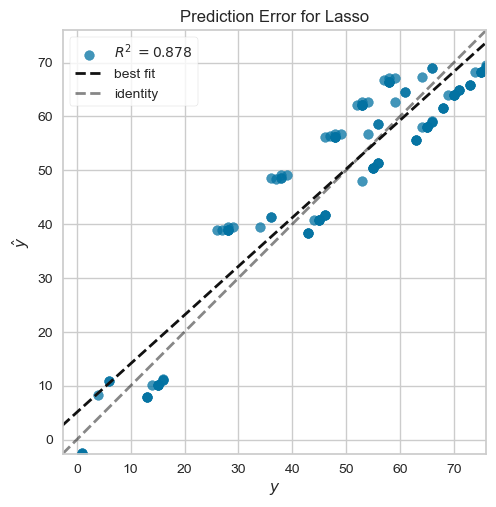

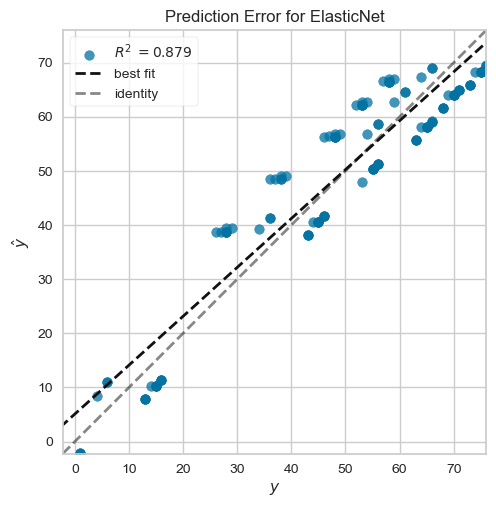

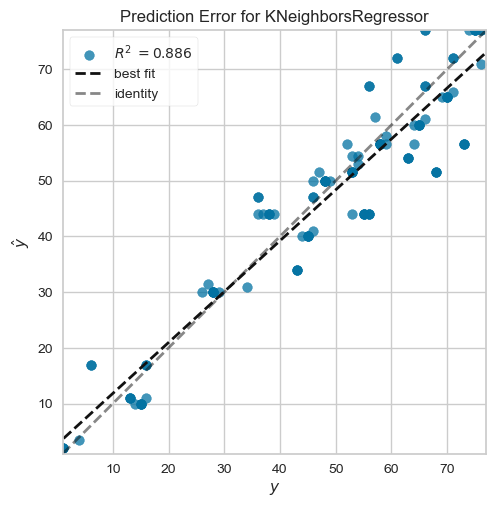

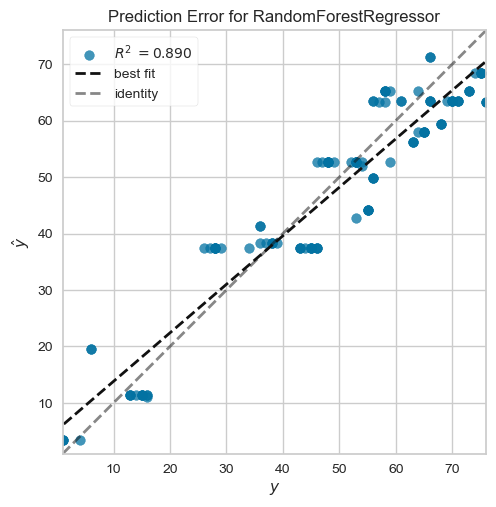

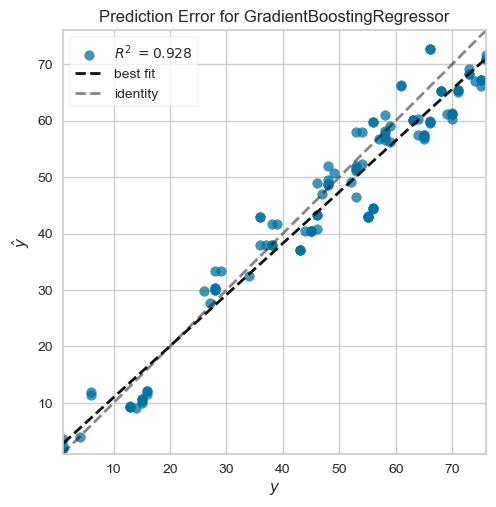

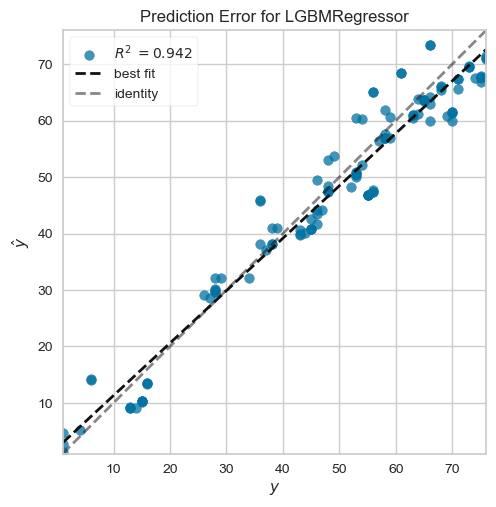

In [11]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_en, plot='error')
plot_model(tuned_knn, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_gbr, plot='error')
plot_model(tuned_lgbm, plot='error')
# plot_model(tuned_ada, plot='error')
# plot_model(tuned_cat, plot='error')
# plot_model(tuned_omp, plot='error')
# plot_model(tuned_huber, plot='error')

In [12]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_en = finalize_model(tuned_en)
final_knn = finalize_model(tuned_knn)
final_rfr = finalize_model(tuned_rfr)
final_gbr = finalize_model(tuned_gbr)
final_lgbm = finalize_model(tuned_lgbm)
# final_ada = finalize_model(tuned_ada)
# final_cat = finalize_model(tuned_cat)
# final_omp = finalize_model(tuned_omp)
# final_huber = finalize_model(tuned_huber)

In [13]:
#--テストデータで予測・評価（収穫日30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST.query("Target_Days <= 30"))
print("KNN")
pred_knn = predict_model(final_knn, data=TEST.query("Target_Days <= 30"))
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST.query("Target_Days <= 30"))
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST.query("Target_Days <= 30"))
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,3.5749,20.8227,4.5632,0.4782,0.3425,0.4889


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,3.5005,20.1168,4.4852,0.4959,0.3359,0.4741


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,5.7368,47.2861,6.8765,-0.1850,0.5525,0.7562


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,4.8336,48.9684,6.9977,-0.2271,0.5514,0.3862


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [14]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST)
print("KNN")
pred_knn = predict_model(final_knn, data=TEST)
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST)
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST)
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST)
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST)
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,5.6378,50.6877,7.1195,0.9037,0.2476,0.2716


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,5.6028,50.6138,7.1143,0.9038,0.2439,0.2653


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,7.7756,92.1373,9.5988,0.8249,0.3876,0.4029


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,7.5728,87.5398,9.3563,0.8337,0.3847,0.2552


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [15]:
#--Lasso回帰の回帰係数をチェック
coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
4,SSD,-0.064914
6,TMP_GDD10,0.025069
7,TmulSSD,-0.003963
16,TmulSSD_05,-0.002907
23,TmulSSD_10,-0.001052
30,TmulSSD_15,0.007822
37,TmulSSD_20,-0.003491
40,APCPRA_25,0.037161
47,APCPRA_30,0.003030
51,TmulSSD_30,-0.005429


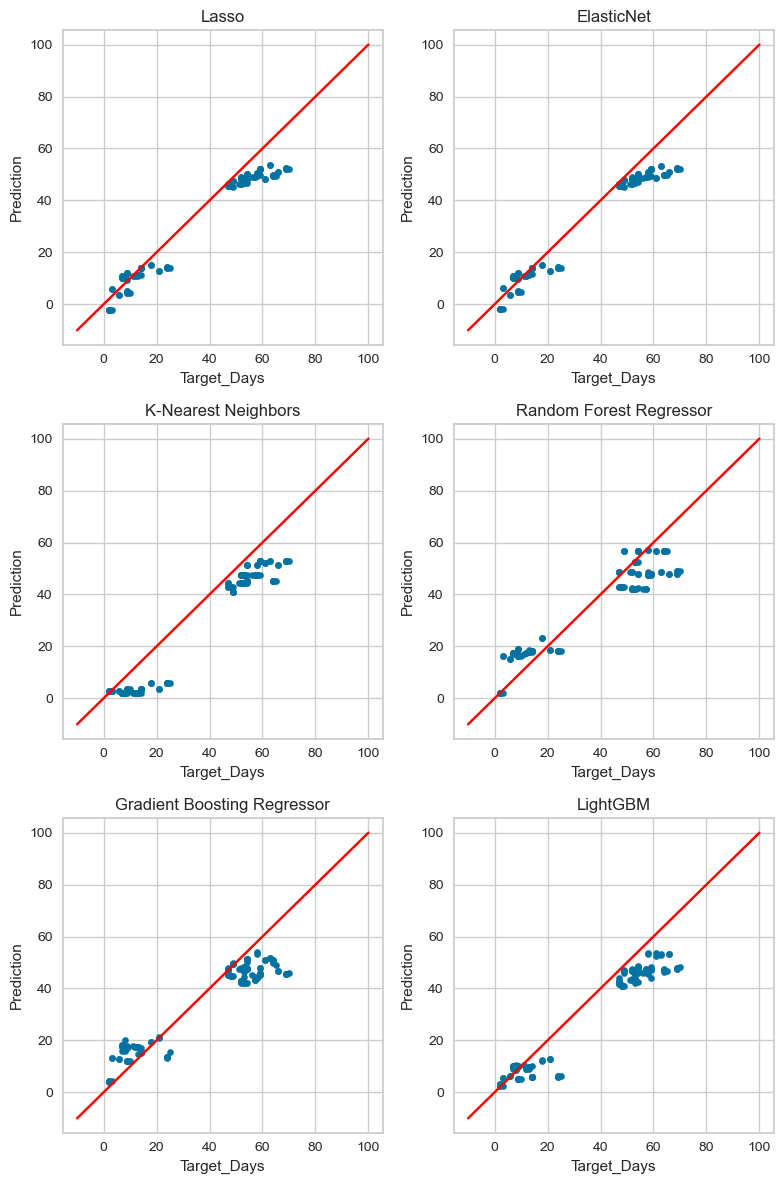

In [16]:
#--予測結果の散布図表示
result = [pred_lasso, pred_en, pred_knn, pred_rfr, pred_gbr, pred_lgbm] #, pred_cat
model_names = ['Lasso', 'ElasticNet', 'K-Nearest Neighbors', 'Random Forest Regressor', 'Gradient Boosting Regressor', 'LightGBM'] #, 'CatBoost'

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,100], [-10,100], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,4.60084,5.364363,0.945321,0.357011


,MAE,RMSE,R2,MAPE
0,5.030612,5.765007,0.16714,0.759464


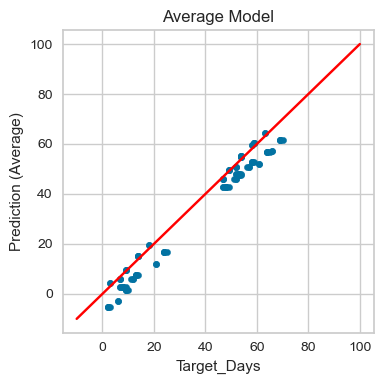

In [17]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,100], [-10,100], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [18]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}_wm"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/kayano1_lasso_model")
save_model(final_en, f"{save_dir}/kayano1_en_model")
save_model(final_knn, f"{save_dir}/kayano1_knn_model")
save_model(final_rfr, f"{save_dir}/kayano1_rfr_model")
save_model(final_gbr, f"{save_dir}/kayano1_gbr_model")
save_model(final_lgbm, f"{save_dir}/kayano1_lgbm_model")
# save_model(final_ada, f"{save_dir}/kayano1_ada_model")
# save_model(final_cat, f"{save_dir}/kayano1_cat_model")
# save_model(final_omp, f"{save_dir}/kayano1_omp_model")
# save_model(final_huber, f"{save_dir}/kayano1_huber_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'TMP_mea',
                                              'APCPRA', 'SSD', 'TMP_GDD0',
                                              'TMP_GDD10', 'TmulSSD', 'RA_days',
                                              'TMP_mea_jan', 'TMP_mea_feb',
                                              'TMP_mea_05', 'APCPRA_05',
                                              'SSD_05', 'TMP_GDD0_05',
                                              'TMP_GDD10_05', 'TmulSSD_05',
                                              'RA_days_05', 'TMP_mea_10',
                                              'APCPRA_10', 'SSD_10',
                                              'TMP_GDD0_10', 'TMP_GDD1...
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('clean_column_names'

# END